# XGBoost - Heart Disease Classification

This notebook is one variant of step **03 - Train & Evaluate Model**.

It reads processed data directly from `data/processed/`, which is generated by `02_Preprocessing.ipynb`. It does not repeat preprocessing inside the training notebook.

In [1]:
# Import common libraries for model training and evaluation
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold

# Keep plot styling consistent with previous notebooks
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10
PAIRED_COLORS = plt.get_cmap("Paired").colors

# Project paths
PROJECT_ROOT = Path("..").resolve()
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
MODELS_DIR = PROJECT_ROOT / "models"
REPORTS_DIR = PROJECT_ROOT / "reports"
FIGURES_DIR = REPORTS_DIR / "figures"
TABLES_DIR = REPORTS_DIR / "tables"

MODELS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42

print(f"Processed data directory: {PROCESSED_DIR}")

Processed data directory: /home/dthanh/Documents/Personal_Doc/ThS/HP2/PPNCKH/Project/heart-disease-classification/data/processed


In [2]:
try:
    from xgboost import XGBClassifier
except ImportError as exc:
    raise ImportError(
        "Package xgboost is required for this notebook. Install it with: DS/bin/pip install xgboost"
    ) from exc

## 1. Load Processed Data

The `X_train`, `X_test`, `y_train`, and `y_test` files are the official outputs of the preprocessing step.

In [3]:
required_files = {
    "X_train": PROCESSED_DIR / "X_train.csv",
    "X_test": PROCESSED_DIR / "X_test.csv",
    "y_train": PROCESSED_DIR / "y_train.csv",
    "y_test": PROCESSED_DIR / "y_test.csv",
}

missing_files = [str(path) for path in required_files.values() if not path.exists()]
if missing_files:
    raise FileNotFoundError(
        "Missing processed data files. Run notebooks/02_Preprocessing.ipynb first "
        "or merge/rebase the preprocessing branch before running this notebook. Missing files: "
        + ", ".join(missing_files)
    )

X_train = pd.read_csv(required_files["X_train"])
X_test = pd.read_csv(required_files["X_test"])
y_train = pd.read_csv(required_files["y_train"])["target"]
y_test = pd.read_csv(required_files["y_test"])["target"]

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape : {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape : {y_test.shape}")

display(X_train.head())

X_train shape: (242, 28)
X_test shape : (61, 28)
y_train shape: (242,)
y_test shape : (61,)


,age,trestbps,chol,thalach,oldpeak,sex_0,sex_1,cp_1,cp_2,cp_3,...,slope_1,slope_2,slope_3,ca_0,ca_1,ca_2,ca_3,thal_3,thal_6,thal_7
0,-0.729485,-0.395692,0.458139,0.708371,-0.445445,0.0,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
1,0.050166,-0.054513,0.230598,0.222495,-0.891627,0.0,1.0,0.0,1.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
2,-0.061212,0.059213,0.723605,0.399178,-0.891627,1.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
3,-0.061212,-1.305501,1.121803,0.266666,-0.891627,0.0,1.0,0.0,1.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
4,0.272924,0.514117,-0.167601,-1.190962,-0.713154,1.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0


## 2. Check Train/Test Target Distribution

This quick check verifies the class ratio after the stratified split.

In [4]:
target_distribution = pd.DataFrame({
    "split": ["train", "test"],
    "n_samples": [len(y_train), len(y_test)],
    "disease_count": [int(y_train.sum()), int(y_test.sum())],
    "disease_percent": [round(y_train.mean() * 100, 2), round(y_test.mean() * 100, 2)],
})

display(target_distribution)
target_distribution.to_csv(TABLES_DIR / "train_test_target_distribution.csv", index=False)

,split,n_samples,disease_count,disease_percent
0,train,242,111,45.87
1,test,61,28,45.90


## 3. Train XGBoost

XGBoost is a gradient boosting model that often performs well on tabular data. This notebook requires the `xgboost` package.

In [5]:
MODEL_PREFIX = "xgb"
MODEL_DISPLAY_NAME = "XGBoost"

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [2, 3, 4],
    "learning_rate": [0.03, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=RANDOM_STATE,
    scale_pos_weight=scale_pos_weight,
    n_jobs=-1,
)

grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    verbose=1,
    refit=True,
)

grid_search.fit(X_train, y_train)
best_model = grid_search.best_estimator_

print("Best params:", grid_search.best_params_)
print(f"Best CV ROC-AUC: {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 48 candidates, totalling 240 fits


Best params: {'colsample_bytree': 0.8, 'learning_rate': 0.03, 'max_depth': 2, 'n_estimators': 100, 'subsample': 0.8}
Best CV ROC-AUC: 0.8939


In [6]:
cv_results = (
    pd.DataFrame(grid_search.cv_results_)
    [["params", "mean_test_score", "std_test_score", "rank_test_score"]]
    .sort_values("rank_test_score")
    .head(10)
    .reset_index(drop=True)
)

display(cv_results)
cv_results.to_csv(TABLES_DIR / f"{MODEL_PREFIX}_cv_results_top10.csv", index=False)

,params,mean_test_score,std_test_score,rank_test_score
0,"{'colsample_bytree': 0.8, 'learning_rate': 0.0...",0.893872,0.021239,1
1,"{'colsample_bytree': 1.0, 'learning_rate': 0.0...",0.892221,0.020860,2
2,"{'colsample_bytree': 0.8, 'learning_rate': 0.0...",0.887866,0.025018,3
3,"{'colsample_bytree': 1.0, 'learning_rate': 0.0...",0.886853,0.026842,4
4,"{'colsample_bytree': 1.0, 'learning_rate': 0.0...",0.883519,0.025825,5
5,"{'colsample_bytree': 0.8, 'learning_rate': 0.0...",0.882826,0.026110,6
6,"{'colsample_bytree': 0.8, 'learning_rate': 0.0...",0.882822,0.027656,7
7,"{'colsample_bytree': 1.0, 'learning_rate': 0.0...",0.882520,0.023604,8
8,"{'colsample_bytree': 0.8, 'learning_rate': 0.0...",0.881591,0.029645,9
9,"{'colsample_bytree': 1.0, 'learning_rate': 0.0...",0.881565,0.028392,10


## 4. Evaluate on Test Set

The test set is used only after hyperparameter selection with cross-validation on the training set.

In [7]:
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

metrics = {
    "Accuracy": round(accuracy_score(y_test, y_pred), 4),
    "Precision": round(precision_score(y_test, y_pred), 4),
    "Recall": round(recall_score(y_test, y_pred), 4),
    "F1-Score": round(f1_score(y_test, y_pred), 4),
    "ROC-AUC": round(roc_auc_score(y_test, y_prob), 4),
}

metrics_df = pd.DataFrame(metrics.items(), columns=["Metric", "Value"])
display(metrics_df)
metrics_df.to_csv(TABLES_DIR / f"{MODEL_PREFIX}_test_metrics.csv", index=False)

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=["No Disease", "Disease"]))

,Metric,Value
0,Accuracy,0.8852
1,Precision,0.8387
2,Recall,0.9286
3,F1-Score,0.8814
4,ROC-AUC,0.9437


Classification Report:
              precision    recall  f1-score   support

  No Disease       0.93      0.85      0.89        33
     Disease       0.84      0.93      0.88        28

    accuracy                           0.89        61
   macro avg       0.89      0.89      0.89        61
weighted avg       0.89      0.89      0.89        61



### 4.1 Confusion Matrix

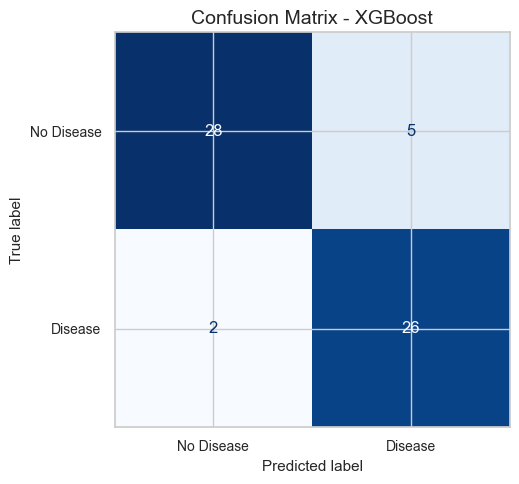

TN=28 | FP=5 | FN=2 | TP=26


In [8]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Disease", "Disease"])
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title(f"Confusion Matrix - {MODEL_DISPLAY_NAME}")
plt.tight_layout()
plt.savefig(FIGURES_DIR / f"{MODEL_PREFIX}_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"TN={tn} | FP={fp} | FN={fn} | TP={tp}")

### 4.2 ROC Curve

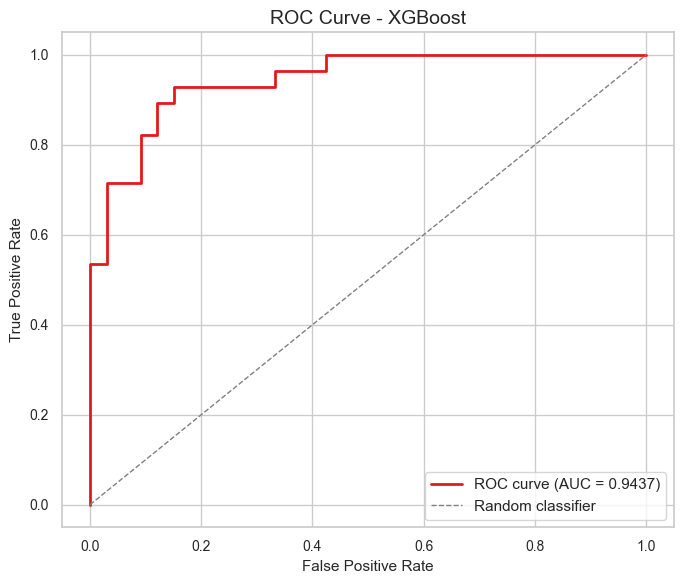

In [9]:
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc_score = metrics["ROC-AUC"]

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr, tpr, color=PAIRED_COLORS[5], lw=2, label=f"ROC curve (AUC = {auc_score:.4f})")
ax.plot([0, 1], [0, 1], color="gray", lw=1, linestyle="--", label="Random classifier")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title(f"ROC Curve - {MODEL_DISPLAY_NAME}")
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig(FIGURES_DIR / f"{MODEL_PREFIX}_roc_curve.png", dpi=300, bbox_inches="tight")
plt.show()

### 4.3 Feature Importance

,feature,importance
0,thal_3,0.176158
1,cp_4,0.106766
2,thal_7,0.094205
3,ca_1,0.065633
4,ca_0,0.059191
5,exang_1,0.053488
6,exang_0,0.051383
7,slope_2,0.047884
8,cp_1,0.041834
9,oldpeak,0.041540


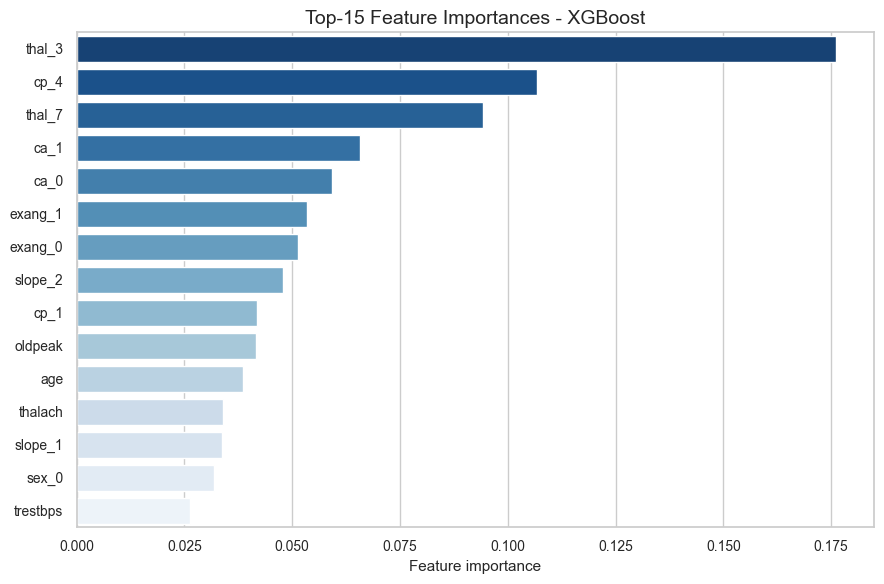

In [10]:
importance_df = (
    pd.DataFrame({"feature": X_train.columns, "importance": best_model.feature_importances_})
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

display(importance_df.head(15))
importance_df.to_csv(TABLES_DIR / f"{MODEL_PREFIX}_feature_importance.csv", index=False)

top15 = importance_df.head(15)
fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(
    data=top15,
    y="feature",
    x="importance",
    hue="feature",
    palette="Blues_r",
    legend=False,
    ax=ax,
)
ax.set_title(f"Top-15 Feature Importances - {MODEL_DISPLAY_NAME}")
ax.set_xlabel("Feature importance")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig(FIGURES_DIR / f"{MODEL_PREFIX}_feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()

### 4.4 Threshold Tuning

For a medical classification task, threshold tuning helps inspect the precision-recall trade-off.

,threshold,precision,recall,f1
37,0.47,0.83871,0.928571,0.881356


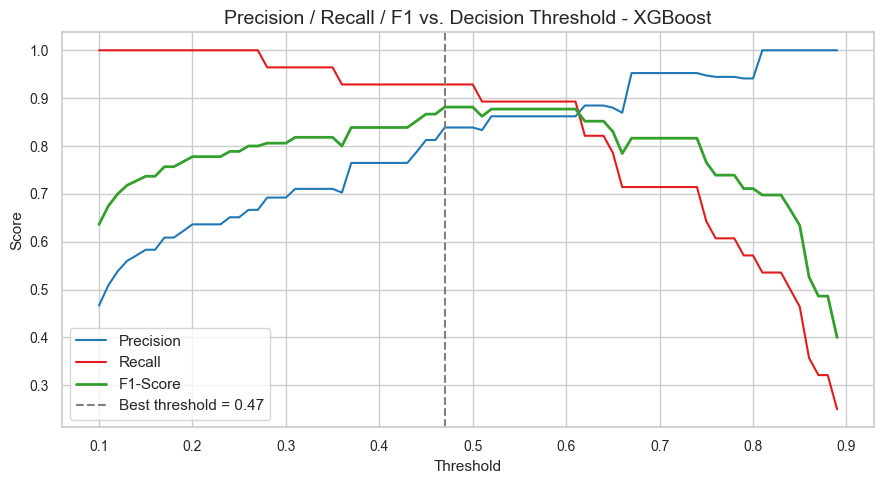

In [11]:
thresholds = np.arange(0.1, 0.9, 0.01)
threshold_rows = []

for threshold in thresholds:
    y_pred_threshold = (y_prob >= threshold).astype(int)
    threshold_rows.append({
        "threshold": round(threshold, 2),
        "precision": precision_score(y_test, y_pred_threshold, zero_division=0),
        "recall": recall_score(y_test, y_pred_threshold, zero_division=0),
        "f1": f1_score(y_test, y_pred_threshold, zero_division=0),
    })

threshold_df = pd.DataFrame(threshold_rows)
best_threshold = threshold_df.loc[threshold_df["f1"].idxmax()]

display(best_threshold.to_frame().T)
threshold_df.to_csv(TABLES_DIR / f"{MODEL_PREFIX}_threshold_tuning.csv", index=False)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(threshold_df["threshold"], threshold_df["precision"], label="Precision", color=PAIRED_COLORS[1])
ax.plot(threshold_df["threshold"], threshold_df["recall"], label="Recall", color=PAIRED_COLORS[5])
ax.plot(threshold_df["threshold"], threshold_df["f1"], label="F1-Score", color=PAIRED_COLORS[3], lw=2)
ax.axvline(best_threshold["threshold"], color="gray", linestyle="--", label=f"Best threshold = {best_threshold['threshold']}")
ax.set_xlabel("Threshold")
ax.set_ylabel("Score")
ax.set_title(f"Precision / Recall / F1 vs. Decision Threshold - {MODEL_DISPLAY_NAME}")
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / f"{MODEL_PREFIX}_threshold_tuning.png", dpi=300, bbox_inches="tight")
plt.show()

## 5. Save Model and Summary

In [12]:
model_path = MODELS_DIR / f"{MODEL_PREFIX}_model.joblib"
joblib.dump(best_model, model_path)

summary_lines = [
    f"# Model Training & Evaluation Summary - {MODEL_DISPLAY_NAME}",
    "",
    "## Input Data",
    "- Training features: `data/processed/X_train.csv`",
    "- Training target: `data/processed/y_train.csv`",
    "- Test features: `data/processed/X_test.csv`",
    "- Test target: `data/processed/y_test.csv`",
    "",
    "## Best Hyperparameters",
]

for key, value in grid_search.best_params_.items():
    summary_lines.append(f"- `{key}`: {value}")

summary_lines += [
    "",
    f"- Best CV ROC-AUC: **{grid_search.best_score_:.4f}**",
    "",
    "## Test-Set Metrics",
    "",
    metrics_df.to_markdown(index=False),
    "",
    "## Threshold Tuning",
    f"- Optimal decision threshold by F1: **{best_threshold['threshold']}**",
    f"- Precision: {best_threshold['precision']:.4f}",
    f"- Recall: {best_threshold['recall']:.4f}",
    f"- F1: {best_threshold['f1']:.4f}",
]

if isinstance(globals().get("importance_df"), pd.DataFrame):
    summary_lines += [
        "",
        "## Top-5 Features",
        "",
        importance_df.head(5).to_markdown(index=False),
    ]

summary_text = "\n".join(summary_lines) + "\n"
summary_path = REPORTS_DIR / f"{MODEL_PREFIX}_model_summary.md"
summary_path.write_text(summary_text, encoding="utf-8")

print(f"Saved model to: {model_path}")
print(f"Saved model summary to: {summary_path}")

Saved model to: /home/dthanh/Documents/Personal_Doc/ThS/HP2/PPNCKH/Project/heart-disease-classification/models/xgb_model.joblib
Saved model summary to: /home/dthanh/Documents/Personal_Doc/ThS/HP2/PPNCKH/Project/heart-disease-classification/reports/xgb_model_summary.md
